In [47]:
#Importando bibliotecas

import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sla

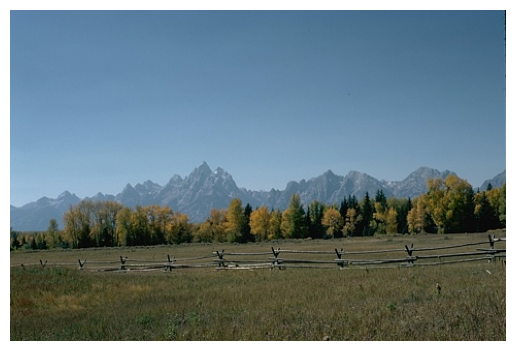

In [48]:
# Carragando imagem

imagem = cv2.imread("imagens_originais/2092.jpg")
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

plt.imshow(imagem_rgb)
plt.axis("off")
plt.show()

In [49]:
# Criando máscara

imagem_corrompida = imagem_rgb.copy()

imagem_corrompida[
    linha_inicio:linha_fim,
    coluna_inicio:coluna_fim
] = [255,255,255]

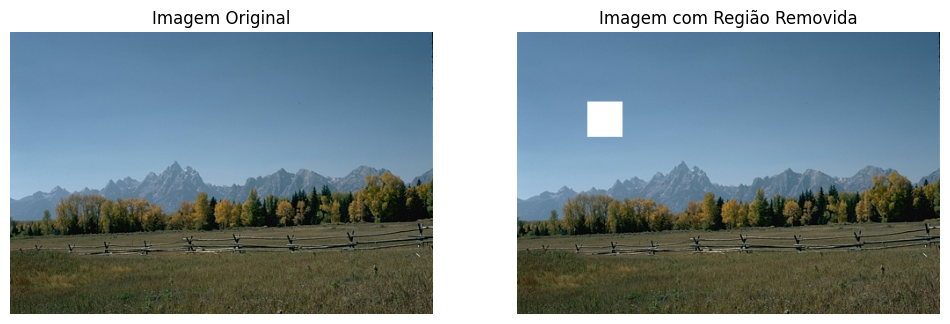

In [50]:
# Imagem original e imagem corrompida

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(imagem_rgb)
ax[0].set_title("Imagem Original")
ax[0].axis("off")

ax[1].imshow(imagem_corrompida)
ax[1].set_title("Imagem com Região Removida")
ax[1].axis("off")

plt.show()

In [51]:
# Convertendo para escala de cinza

gray = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

gray_corrompida = gray.copy()

gray_corrompida[
    linha_inicio:linha_fim,
    coluna_inicio:coluna_fim
] = 255

In [52]:
# Mapeando espaço faltante na imagem

indices = {}

contador = 0

for i in range(linha_inicio, linha_fim):
    for j in range(coluna_inicio, coluna_fim):

        indices[(i,j)] = contador

        contador += 1

n = contador

In [53]:
# Montando matriz A e vetor b

A = np.zeros((n,n))

b_r = np.zeros(n)

b_g = np.zeros(n)

b_b = np.zeros(n)

for (i,j), k in indices.items():

    A[k,k] = -4

    vizinhos = [
        (i-1,j),
        (i+1,j),
        (i,j-1),
        (i,j+1)
    ]

    for vi,vj in vizinhos:

        if (vi,vj) in indices:

            indice_vizinho = indices[(vi,vj)]

            A[k,indice_vizinho] = 1

        else:

            b_r[k] -= imagem_rgb[vi,vj,0]

            b_g[k] -= imagem_rgb[vi,vj,1]

            b_b[k] -= imagem_rgb[vi,vj,2]

In [54]:
# Resolvendo sistema com LU

LU, piv = sla.lu_factor(A)

x_r = sla.lu_solve((LU,piv), b_r)

x_g = sla.lu_solve((LU,piv), b_g)

x_b = sla.lu_solve((LU,piv), b_b)

In [56]:
# Reconstruindo imagem

imagem_reconstruida = imagem_corrompida.copy()

for (i,j), k in indices.items():

    r = int(np.clip(x_r[k],0,255))

    g = int(np.clip(x_g[k],0,255))

    b = int(np.clip(x_b[k],0,255))

    imagem_reconstruida[i,j] = [r,g,b]

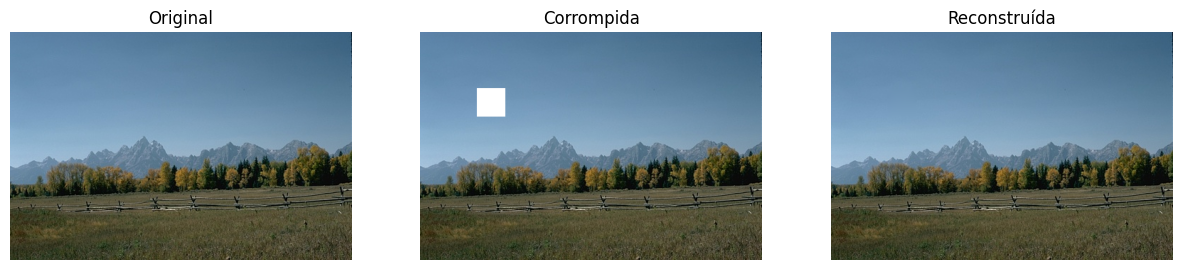

In [57]:
# Mostrando resultado final

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(imagem_rgb)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(imagem_corrompida)
ax[1].set_title("Corrompida")
ax[1].axis("off")

ax[2].imshow(imagem_reconstruida)
ax[2].set_title("Reconstruída")
ax[2].axis("off")

plt.show()